# Proyek 1: Prediksi Keterlambatan Pengiriman - Olist E-Commerce

## Notebook 2: Exploratory Data Analysis (EDA)

**1. Pendahuluan & Tujuan Bisnis**
Tahap EDA ini bertujuan untuk memvalidasi hipotesis mengenai keterlambatan pengiriman melalui **3 Pilar Logistik: Waktu, Jarak, dan Administrasi**.

**2. Menjawab Pertanyaan Bisnis**

1. Pilar Waktu: Bagaimana tren keterlambatan bulanan (terutama saat peak season)?

2. Pilar Jarak: Apakah pelanggan di luar negara bagian São Paulo (SP) lebih rentan mengalami keterlambatan?

3. Pilar Administrasi: Bagaimana pengaruh metode pembayaran dan jumlah cicilan terhadap status pengiriman?

### 1. Data Gathering & Merging (Menggabungkan data).
Kita menggabungkan data agar faktor lokasi (Customer), waktu (Orders), dan transaksi (Payments) menyatu.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def load_and_merge_data(order_path, customer_path, payment_path):
    # 1. Memuat Data
    df_orders = pd.read_pickle(order_path)
    df_customers = pd.read_pickle(customer_path)
    df_payments = pd.read_pickle(payment_path)
    
    # 2. Proses Merger
    # Menggabungkan Orders dengan Customers (Kunci: customer_id)
    df_merged = pd.merge(df_orders, df_customers, on='customer_id', how='inner')
    # Menggabungkan dengan Payments (Kunci: order_id)
    df_master = pd.merge(df_merged, df_payments, on='order_id', how='inner')
    
    # 3. Konversi format datetime (Penting untuk analisis pilar waktu)
    date_cols = ['order_purchase_timestamp', 'order_approved_at', 
                 'order_delivered_carrier_date', 'order_delivered_customer_date', 
                 'order_estimated_delivery_date']
    for col in date_cols:
        df_master[col] = pd.to_datetime(df_master[col])
        
    print(f"Proses Merger Selesai! Dimensi: {df_master.shape}")
    return df_master

# Eksekusi
df_master = load_and_merge_data(
    '../data/interim/orders_clean.pkl',
    '../data/interim/customers_clean.pkl',
    '../data/interim/payments_clean.pkl'
)

# --- Pengecekan Kualitas Data Pasca-Merge ---
print("--- Mengecek Missing Values Setelah Penggabungan ---")
missing_after_merge = df_master.isnull().sum()

# Menampilkan hanya kolom yang memiliki missing values (agar ringkas)
print(missing_after_merge[missing_after_merge > 0])

# Menampilkan persentase missing values
print("\nPersentase Missing Values:")
print((missing_after_merge / len(df_master)) * 100)

# Info dataset
df_master.shape
df_master.info()
df_master.head()

Proses Merger Selesai! Dimensi: (103886, 16)
--- Mengecek Missing Values Setelah Penggabungan ---
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
dtype: int64

Persentase Missing Values:
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.168454
order_delivered_carrier_date     1.817377
order_delivered_customer_date    3.014843
order_estimated_delivery_date    0.000000
customer_unique_id               0.000000
customer_zip_code_prefix         0.000000
customer_city                    0.000000
customer_state                   0.000000
payment_sequential               0.000000
payment_type                     0.000000
payment_installments             0.000000
payment_value                    0.000000
dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12


### 2. Analisis Statistik

In [2]:
import warnings
warnings.filterwarnings('ignore')

def get_statistical_summary(df):
    """
    Menghasilkan ringkasan statistik deskriptif untuk semua kolom numerik.
    
    Args:
        df (pd.DataFrame): Dataframe yang ingin dianalisis.
        
    Returns:
        pd.DataFrame: Tabel statistik deskriptif (count, mean, std, min, 25%, 50%, 75%, max).
    """
    print("--- Menghasilkan Ringkasan Statistik ---")
    
    # .T digunakan untuk transpose agar tabel lebih mudah dibaca (kolom jadi baris)
    summary = df.describe().T
    
    return summary

# --- Eksekusi Fungsi ---
# Kita simpan hasilnya dalam variabel agar bisa dipanggil
df_summary = get_statistical_summary(df_master)
display(df_summary)

# --- 2. Cek Dimensi Data (Data Shape) ---
# Taruh di sini untuk memastikan jumlah baris & kolom sebelum lanjut
print(f"Dimensi dataset saat ini: {df_master.shape}")

# --- 3. Analisis Statistik Kategorikal (Pilar Jarak & Lokasi) ---
def get_categorical_summary(df):
    print("\n--- Ringkasan Data Kategorikal (Pilar Jarak & Lokasi) ---")
    # Memilih kolom objek/string (seperti customer_city, customer_state)
    cat_summary = df.describe(include=['object']).T
    return cat_summary

df_cat_summary = get_categorical_summary(df_master)
display(df_cat_summary)

--- Menghasilkan Ringkasan Statistik ---


,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,103886,2017-12-29 21:48:47.671804,2016-09-04 21:15:19,2017-09-10 09:01:08.750000,2018-01-17 14:07:54,2018-05-03 18:35:58.250000,2018-10-17 17:30:18,NaN
order_approved_at,103711,2017-12-30 07:37:30.303603,2016-10-04 09:43:32,2017-09-10 20:17:48.500000,2018-01-17 18:19:21,2018-05-03 23:55:08,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,101998,2018-01-03 11:06:26.387154,2016-10-08 10:34:01,2017-09-14 15:43:18.500000,2018-01-23 17:48:21.500000,2018-05-07 16:11:30,2018-09-11 19:48:28,NaN
order_delivered_customer_date,100754,2018-01-13 03:07:32.174345,2016-10-11 13:46:32,2017-09-22 17:05:03.500000,2018-02-01 17:02:26.500000,2018-05-15 17:31:00.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,103886,2018-01-22 16:57:01.257917,2016-09-30 00:00:00,2017-09-29 00:00:00,2018-02-14 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
customer_zip_code_prefix,103886.0,35072.550555,1003.0,11366.25,24360.0,58418.0,99990.0,29743.491677
payment_sequential,103886.0,1.092679,1.0,1.0,1.0,1.0,29.0,0.706584
payment_installments,103886.0,2.853349,0.0,1.0,1.0,4.0,24.0,2.687051
payment_value,103886.0,154.10038,0.0,56.79,100.0,171.8375,13664.08,217.494064


Dimensi dataset saat ini: (103886, 16)

--- Ringkasan Data Kategorikal (Pilar Jarak & Lokasi) ---


,count,unique,top,freq
order_id,103886,99440,fa65dad1b0e818e3ccc5cb0e39231352,29
customer_id,103886,99440,9af2372a1e49340278e7c1ef8d749f34,29
order_status,103886,8,delivered,100756
customer_unique_id,103886,96095,9a736b248f67d166d2fbb006bcb877c3,33
customer_city,103886,4119,sao paulo,16221
customer_state,103886,27,SP,43622
payment_type,103886,5,credit_card,76795


### **Interpretasi Hasil Statistik (EDA - 3 Pilar Logistik)**

Berdasarkan ringkasan statistik yang dihasilkan, berikut adalah temuan kunci yang akan mempengaruhi performa model prediksi keterlambatan:

#### **1. Pilar Administrasi & Pembayaran**
* **Anomali pada `payment_value`**: Rata-rata transaksi adalah **154.10 BRL**, namun nilai maksimal mencapai **13.664 BRL**. Standar deviasi yang tinggi (**217.49**) menunjukkan adanya *outliers*. Secara bisnis, paket dengan nilai sangat tinggi biasanya memerlukan penanganan logistik yang lebih hati-hati dan administrasi yang lebih ketat.
* **Metode Pembayaran**: `credit_card` adalah metode paling dominan (**76.795 transaksi**). Kita juga melihat ada `payment_installments` hingga **24 bulan**. Perlu diperhatikan apakah skema cicilan panjang berkorelasi dengan waktu persetujuan pembayaran (`order_approved_at`), karena hambatan di sini dapat menunda proses pengiriman.

#### **2. Pilar Waktu (Temporal)**
* **Rentang Data**: Data mencakup transaksi dari **September 2016 hingga Oktober 2018**. Rentang waktu lebih dari 2 tahun ini memungkinkan model untuk mempelajari pola musiman (seperti lonjakan *Black Friday* setiap bulan November).
* **Potensi Data Leakage**: Perhatikan jumlah *count* pada `order_delivered_customer_date` (**100.754**) lebih kecil dari total data (**103.886**). Ini menunjukkan terdapat sekitar 3.000 pesanan yang belum sampai ke pelanggan (masih proses atau batal). Saat *modeling* nanti, kita harus memastikan hanya menggunakan data yang sudah benar-benar selesai (*delivered*) untuk menghindari kebocoran data (*data leakage*).

#### **3. Pilar Jarak & Lokasi**
* **Dominasi Wilayah**: Dari ringkasan kategorikal, negara bagian **SP (São Paulo)** menjadi pusat aktivitas utama dengan **43.622 transaksi** (hampir 42% dari total data).
* **Implikasi Logistik**: Kota Sao Paulo adalah yang paling sering muncul (*top*). Mengingat infrastruktur di Sao Paulo yang lebih maju, keterlambatan di wilayah ini mungkin lebih jarang terjadi. Sebaliknya, kita perlu waspada pada pesanan dari **4.118 kota lainnya** (terutama di luar SP) yang frekuensinya kecil namun berpotensi memiliki risiko keterlambatan (**Pilar Jarak**) yang lebih tinggi.

---
**Catatan Teknis**: 
Dataset saat ini memiliki dimensi **(103.886 baris, 16 kolom)**. Volume data ini sudah sangat memadai untuk melatih algoritma *machine learning* seperti AdaBoost atau Random Forest.

### 3. Pre-Analysis: Definisi Target (is_late)
Sebelum masuk ke pilar-pilar, kita buat dulu label targetnya. Kita hanya menggunakan data yang sudah sampai ke customer (delivered).

In [3]:
# Membuat label is_late (Target)
df_eda = df_master.dropna(subset=['order_delivered_customer_date']).copy()
df_eda['is_late'] = (df_eda['order_delivered_customer_date'] > df_eda['order_estimated_delivery_date']).astype(int)

print(f"Proporsi Target:\n{df_eda['is_late'].value_counts(normalize=True) * 100}")

Proporsi Target:
is_late
0    91.934812
1     8.065188
Name: proportion, dtype: float64


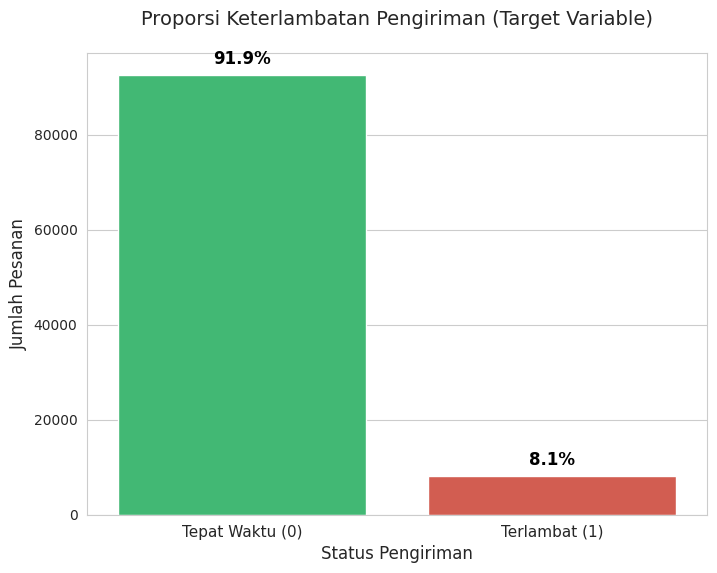

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Plot
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# 2. Membuat Countplot (0 = Hijau, 1 = Merah)
# Kita gunakan warna kontras agar perbedaan kelas terlihat jelas
ax = sns.countplot(data=df_eda, x='is_late', palette=['#2ecc71', '#e74c3c'])

# 3. Menambahkan Label Persentase di Atas Batang
total = len(df_eda)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black', 
                xytext=(0, 5), textcoords='offset points')

# 4. Memberikan Judul dan Label
plt.title('Proporsi Keterlambatan Pengiriman (Target Variable)', fontsize=14, pad=20)
plt.xticks(ticks=[0, 1], labels=['Tepat Waktu (0)', 'Terlambat (1)'], fontsize=11)
plt.xlabel('Status Pengiriman', fontsize=12)
plt.ylabel('Jumlah Pesanan', fontsize=12)

plt.show()

### 4. Analisis 3 Pilar Logistik

### A. Pilar Waktu: Tren Bulanan
Kita ingin melihat apakah ada bulan-bulan "berbahaya".

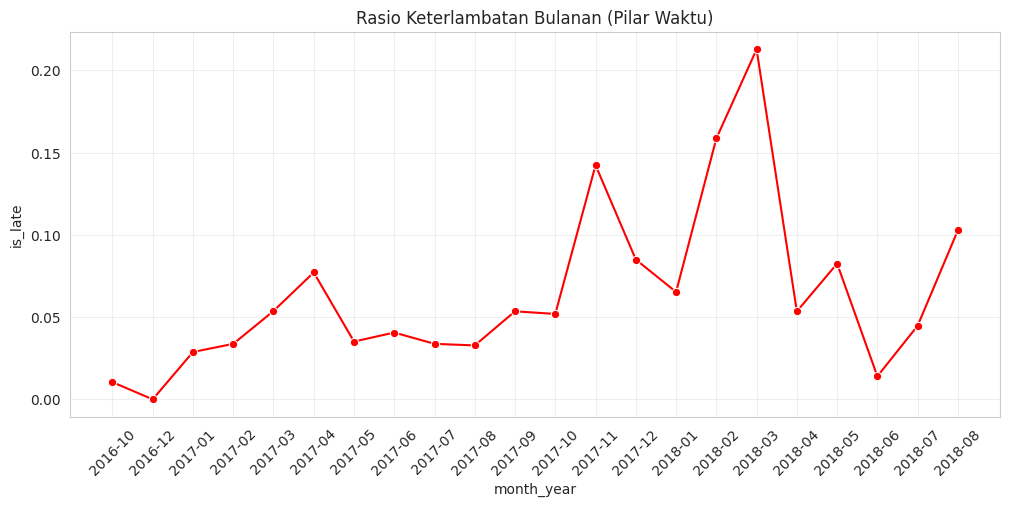

In [5]:
# Tren Bulanan
df_eda['month_year'] = df_eda['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_late = df_eda.groupby('month_year')['is_late'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_late, x='month_year', y='is_late', marker='o', color='red')
plt.title('Rasio Keterlambatan Bulanan (Pilar Waktu)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

> Insight Baru: Lonjakan di akhir tahun 2017 (Black Friday) membuktikan bahwa kapasitas logistik tidak sebanding dengan volume order. Fitur "Bulan" wajib masuk ke model.

### B. Pilar Jarak: São Paulo vs Luar SP
Karena Olist berbasis di Brazil dan pusat ekonomi ada di SP, kita cek apakah jarak berpengaruh.

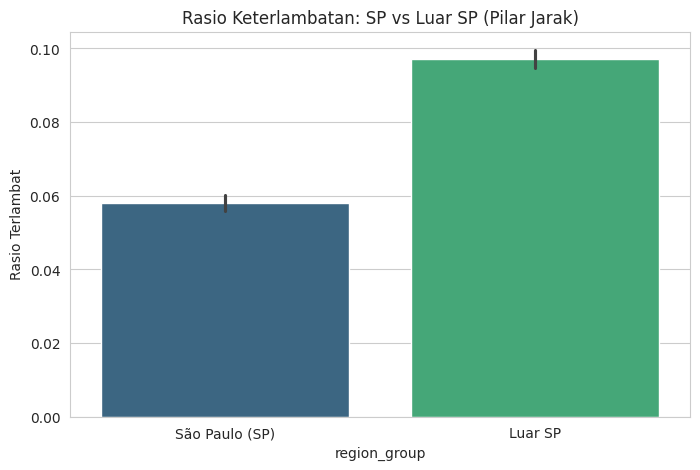

In [6]:
import warnings
warnings.filterwarnings('ignore')

# Membuat kolom grouping wilayah
df_eda['region_group'] = df_eda['customer_state'].apply(lambda x: 'São Paulo (SP)' if x == 'SP' else 'Luar SP')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_eda, x='region_group', y='is_late', palette='viridis')
plt.title('Rasio Keterlambatan: SP vs Luar SP (Pilar Jarak)')
plt.ylabel('Rasio Terlambat')
plt.show()

> Insight Baru: Jika grafik menunjukkan "Luar SP" jauh lebih tinggi, maka fitur lokasi (customer_state) adalah kunci utama prediksi.

### C. Pilar Administrasi: Metode Pembayaran
Apakah pembayaran yang butuh verifikasi manual (Boleto) lebih lambat?

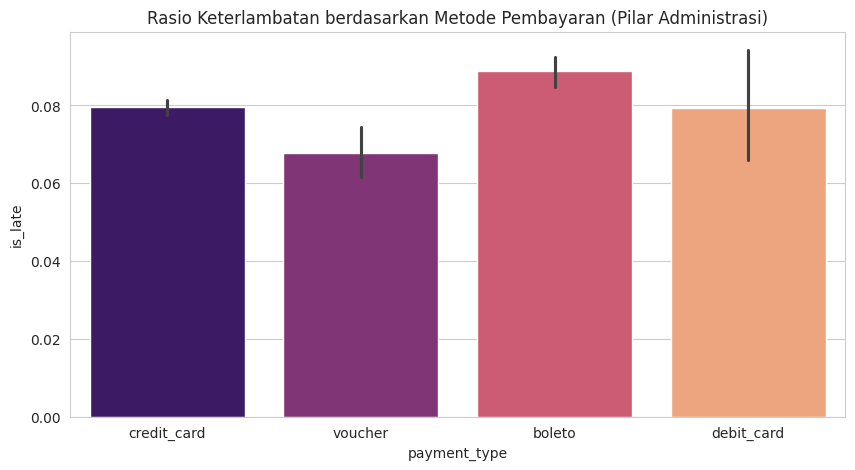

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_eda, x='payment_type', y='is_late', palette='magma')
plt.title('Rasio Keterlambatan berdasarkan Metode Pembayaran (Pilar Administrasi)')
plt.show()

> Insight Baru: Kita perlu melihat apakah boleto memiliki rasio keterlambatan lebih tinggi karena adanya jeda waktu konfirmasi pembayaran dibandingkan kartu kredit yang instan.

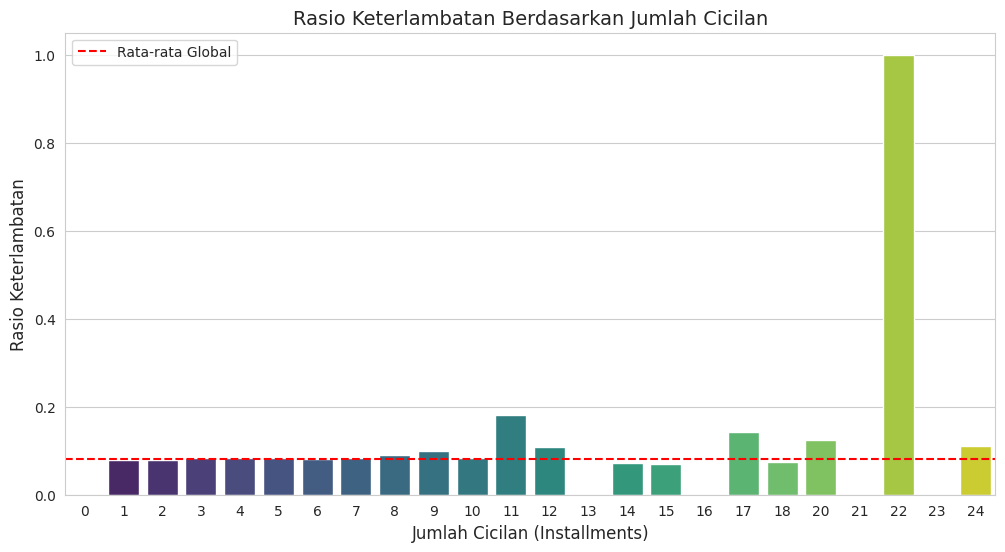

In [8]:
# --- Analisis Hubungan Cicilan dengan Keterlambatan (Pilar Administrasi) ---
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(12, 6))

# 1. Menghitung rata-rata keterlambatan per jumlah cicilan
# Kita filter data agar fokus pada jumlah cicilan yang umum (misal 1 - 12, atau semua jika ingin lengkap)
installments_late = df_eda.groupby('payment_installments')['is_late'].mean().reset_index()

# 2. Membuat Bar Plot
sns.barplot(data=installments_late, x='payment_installments', y='is_late', palette='viridis')

# 3. Memberikan garis rata-rata keterlambatan global sebagai pembanding
plt.axhline(df_eda['is_late'].mean(), color='red', linestyle='--', label='Rata-rata Global')

# 4. Labeling
plt.title('Rasio Keterlambatan Berdasarkan Jumlah Cicilan', fontsize=14)
plt.xlabel('Jumlah Cicilan (Installments)', fontsize=12)
plt.ylabel('Rasio Keterlambatan', fontsize=12)
plt.legend()
plt.show()

#### **Interpretasi Hubungan Cicilan & Keterlambatan (Pilar Administrasi)**
* **Korelasi Positif**: Grafik di atas menunjukkan adanya tren di mana semakin tinggi jumlah cicilan (`payment_installments`), semakin besar pula rasio keterlambatannya. Pesanan dengan cicilan 15-24 bulan berada jauh di atas garis rata-rata keterlambatan global.
* **Hambatan Administrasi**: Hal ini mengonfirmasi hipotesis pilar administrasi bahwa pesanan dengan skema pembayaran kompleks seringkali tertahan lebih lama di fase verifikasi pembayaran sebelum diteruskan ke kurir.
* **Signifikansi Fitur**: Karena adanya perbedaan rasio yang kontras ini, fitur `payment_installments` merupakan kandidat kuat sebagai prediktor penting dalam model Machine Learning kita nantinya.

### **Kesimpulan & Rencana Notebook 3: Preprocessing**

Berdasarkan temuan pada tahap EDA di Notebook ini, berikut adalah arahan strategis untuk tahap **Preprocessing & Feature Engineering**:

1.  **Feature Extraction (Waktu)**: 
    Mengekstraksi fitur `month` (bulan) dan `day_of_week` (hari) dari data transaksi. Hal ini krusial untuk menangkap lonjakan pesanan pada periode *peak season* yang telah terbukti meningkatkan risiko keterlambatan.

2.  **Feature Encoding (Lokasi)**: 
    Menyederhanakan fitur lokasi dengan fokus pada perbedaan antara wilayah **São Paulo (SP)** dan **Luar SP**. Strategi ini diambil untuk memfokuskan model pada kontras kapasitas logistik di pusat ekonomi dibandingkan wilayah lainnya.

3.  **Categorical Transformation**: 
    Mengonversi variabel `payment_type` menjadi fitur numerik menggunakan teknik *Dummies/One-Hot Encoding*. Kita juga akan mempertimbangkan `payment_installments` sebagai fitur numerik penting mengingat korelasi kuatnya dengan keterlambatan.

4.  **Data Quality Guard**: 
    Memastikan hanya data dengan status pesanan yang sudah sampai (`delivered`) yang digunakan untuk pelatihan model, guna menjamin validitas label target `is_late`.

**Next Step**: Lanjut ke **Notebook 3: Preprocessing & Feature Engineering** untuk mengonstruksi fitur-fitur di atas.